# Module 3 — Log Clustering for Pattern Discovery

Welcome to **Module 3 of Applied ML for AIOps**! In this notebook, you'll transform unstructured log text into meaningful clusters that reveal operational patterns.

**Learning Objectives:**
- Understand why logs are crucial for AIOps
- Master TF-IDF for text vectorization
- Apply K-Means clustering to group similar logs
- Interpret and label clusters for operational insights
- Export findings for monitoring and automation

Each section below corresponds to lessons in the left panel.

## Lesson 3.1 — Why Logs Matter in AIOps

Preview the log file to understand its structure and content.

In [2]:
print(" Previewing first 20 lines of app_logs.txt...")
print("=" * 60)
!head -n 20 /app/notebooks/data/app_logs.txt
print("=" * 60)

print("\n Observation: Look for patterns in log structure - timestamps, log levels,")
print("   service names, and message types that repeat across different entries.")

 Previewing first 20 lines of app_logs.txt...
,"54.36.149.41 - - [22/Jan/2019:03:56:14 +0330] ""GET /filter/27|13%20%D9%85%DA%AF%D8%A7%D9%BE%DB%8C%DA%A9%D8%B3%D9%84,27|%DA%A9%D9%85%D8%AA%D8%B1%20%D8%A7%D8%B2%205%20%D9%85%DA%AF%D8%A7%D9%BE%DB%8C%DA%A9%D8%B3%D9%84,p53 HTTP/1.1"" 200 30577 ""-"" ""Mozilla/5.0 (compatible; AhrefsBot/6.1; +http://ahrefs.com/robot/)"" ""-"""
3089189,"5.210.140.170 - - [23/Jan/2019:12:43:40 +0330] ""GET /apple-touch-icon-120x120.png HTTP/1.1"" 404 33679 ""-"" ""MobileSafari/604.1 CFNetwork/976 Darwin/18.2.0"" ""-"""
6073343,"66.249.66.91 - - [24/Jan/2019:21:17:43 +0330] ""GET /static/images/guarantees/bestPrice.png HTTP/1.1"" 304 0 ""-"" ""Googlebot-Image/1.0"" ""-"""
9392152,"5.200.69.130 - - [26/Jan/2019:13:54:06 +0330] ""GET /image/1/brand HTTP/1.1"" 200 3924 ""https://www.zanbil.ir/filter/b1,p62"" ""Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/71.0.3578.98 Safari/537.36"" ""-"""
4366289,"5.208.174.46 - - [23/Jan/

### Your Turn: Analyze Log Structure

Complete the code below to analyze web server access patterns:

In [3]:
# SOLUTION: Comprehensive log pattern analysis for WEB SERVER ACCESS LOGS

print(" Web Server Access Log Analysis")
print("=" * 60)

# TODO: Load the log data
# Your code here: Use with open() to read the file
with open('/app/notebooks/data/app_logs.txt', 'r') as f:
    lines = [line.strip() for line in f]

print(f" Loaded {len(lines)} web access log entries for analysis")

# TODO: Analyze HTTP methods
http_methods = ['GET', 'POST', 'PUT', 'DELETE', 'HEAD']
method_counts = {}

for method in http_methods:
    # Your code here: Count how many times each HTTP method appears
    count = sum(1 for line in lines if f"{method} " in line)
    method_counts[method] = count
    print(f"{method}: {count} occurrences")

# TODO: Analyze HTTP status codes
status_codes = ['200', '404', '304', '301', '500']
status_counts = {}
import re

status_code_regex = re.compile(r"\s(\d{3})\s")
for code in status_codes:
    # Your code here: Count how many times each HTTP status code appears
    count = 0
    for line in lines:
        m = status_code_regex.search(line)
        if m and m.group(1) == code:
            count += 1
    status_counts[code] = count
    print(f"HTTP {code}: {count} occurrences")

# TODO: Identify common patterns in web access logs
def count_if(predicate):
    return sum(1 for line in lines if predicate(line))

common_patterns = {
    'Image requests': count_if(lambda l: '/image/' in l or any(ext in l for ext in ['.png', '.jpg', '.jpeg', '.gif', '.webp'])),
    'Static file requests': count_if(lambda l: '/static/' in l or any(ext in l for ext in ['.css', '.js', '.woff', '.woff2', '.ttf'])),
    'API endpoints': count_if(lambda l: any(api in l for api in ['/filter', '/ajax', '/api', '/settings'])),
    'Mobile requests': count_if(lambda l: any(mobile in l for mobile in ['Mobile', 'Android', 'iPhone', 'iPad'])),
    'Bot/Crawler traffic': count_if(lambda l: any(bot in l for bot in ['bot', 'Bot', 'crawler', 'Crawler', 'Googlebot', 'bingbot']))
}

print("\n Common Web Access Patterns:")
for pattern, count in common_patterns.items():
    # Your code here: Calculate percentage
    percentage = (count / len(lines)) * 100
    print(f"   {pattern}: {count} ({percentage:.1f}%)")

# TODO: Additional insights for web logs
print(f"\n Additional Web Log Insights:")
print(f"   Total requests: {len(lines)}")
# Your code here: Calculate success rate
success_rate = (status_counts.get('200', 0) / len(lines)) * 100
# Your code here: Calculate error rate
error_rate = ((status_counts.get('404', 0) + status_counts.get('500', 0)) / len(lines)) * 100
print(f"   Success rate (HTTP 200): {success_rate:.1f}%")
print(f"   Error rate (HTTP 404/500): {error_rate:.1f}%")

print("\n These are web server access logs showing HTTP traffic patterns!")
print("   Look for: successful vs failed requests, bot traffic, mobile vs desktop, popular endpoints")

 Web Server Access Log Analysis
 Loaded 10001 web access log entries for analysis
GET: 9823 occurrences
POST: 144 occurrences
PUT: 0 occurrences
DELETE: 0 occurrences
HEAD: 34 occurrences
HTTP 200: 9220 occurrences
HTTP 404: 108 occurrences
HTTP 304: 355 occurrences
HTTP 301: 55 occurrences
HTTP 500: 14 occurrences

 Common Web Access Patterns:
   Image requests: 6952 (69.5%)
   Static file requests: 2003 (20.0%)
   API endpoints: 3270 (32.7%)
   Mobile requests: 4419 (44.2%)
   Bot/Crawler traffic: 1084 (10.8%)

 Additional Web Log Insights:
   Total requests: 10001
   Success rate (HTTP 200): 92.2%
   Error rate (HTTP 404/500): 1.2%

 These are web server access logs showing HTTP traffic patterns!
   Look for: successful vs failed requests, bot traffic, mobile vs desktop, popular endpoints


## Lesson 3.2 — The Challenge: Unstructured, Unlabeled Data

Load logs into Pandas and clean the text for analysis.

In [4]:
import pandas as pd

print(" Loading and sampling log data...")

# Sample only a portion of the data to avoid memory issues
sample_size = 5000  # Adjust this based on your system memory

# Read the file and sample lines
with open('/app/notebooks/data/app_logs.txt', 'r') as f:
    lines = []
    for i, line in enumerate(f):
        if i >= sample_size:
            break
        lines.append(line.strip())

# Parse each line - extract the message after the first comma
parsed_logs = []
for line in lines:
    if line and ',' in line:
        # Split on first comma only, take the message part
        message = line.split(',', 1)[1].strip()
        # Remove surrounding quotes if present
        if message.startswith('"') and message.endswith('"'):
            message = message[1:-1]
        parsed_logs.append(message)

# Create DataFrame
df_logs = pd.DataFrame(parsed_logs, columns=['message_raw'])
df_logs['message_clean'] = df_logs['message_raw'].astype(str).str.strip().str.lower()

# Display dataset info
print(" Dataset loaded successfully!")
print(f"   Total log entries sampled: {len(df_logs):,}")
print(f"   Sample entries:")
print("-" * 50)
display(df_logs[['message_raw', 'message_clean']].head(8))

print(" Note: Using a sample of data to prevent memory issues.")
print("   Text normalization helps ML models recognize similar messages.")

 Loading and sampling log data...
 Dataset loaded successfully!
   Total log entries sampled: 5,000
   Sample entries:
--------------------------------------------------


,message_raw,message_clean
0,54.36.149.41 - - [22/Jan/2019:03:56:14 +0330] ...,54.36.149.41 - - [22/jan/2019:03:56:14 +0330] ...
1,5.210.140.170 - - [23/Jan/2019:12:43:40 +0330]...,5.210.140.170 - - [23/jan/2019:12:43:40 +0330]...
2,66.249.66.91 - - [24/Jan/2019:21:17:43 +0330] ...,66.249.66.91 - - [24/jan/2019:21:17:43 +0330] ...
3,5.200.69.130 - - [26/Jan/2019:13:54:06 +0330] ...,5.200.69.130 - - [26/jan/2019:13:54:06 +0330] ...
4,5.208.174.46 - - [23/Jan/2019:22:52:04 +0330] ...,5.208.174.46 - - [23/jan/2019:22:52:04 +0330] ...
5,66.249.66.91 - - [22/Jan/2019:16:08:43 +0330] ...,66.249.66.91 - - [22/jan/2019:16:08:43 +0330] ...
6,54.36.148.208 - - [26/Jan/2019:08:17:03 +0330]...,54.36.148.208 - - [26/jan/2019:08:17:03 +0330]...
7,86.107.144.192 - - [24/Jan/2019:19:01:58 +0330...,86.107.144.192 - - [24/jan/2019:19:01:58 +0330...


 Note: Using a sample of data to prevent memory issues.
   Text normalization helps ML models recognize similar messages.


### Your Turn: Advanced Log Cleaning and Analysis

Complete the pattern extraction function below:

In [5]:
# SOLUTION: Advanced web log cleaning focused on clustering patterns

print(" Web Log Pattern Extraction")
print("=" * 60)

# TODO: Import required module for regex
import re

def extract_log_pattern(log_line):
    """Extract key components from web server log for clustering"""
    try:
        # TODO: Extract HTTP method and URL path
        if 'GET ' in log_line:
            method = 'get'
            # Your code here: Extract URL path between "GET " and " HTTP"
            url_start = log_line.find('GET ') + 4
            url_end = log_line.find(' HTTP', url_start)
            url_end = url_end if url_end != -1 else len(log_line)
            url_path = log_line[url_start:url_end].strip()
        elif 'POST ' in log_line:
            method = 'post'
            # Your code here: Extract URL path
            url_start = log_line.find('POST ') + 5
            url_end = log_line.find(' HTTP', url_start)
            url_end = url_end if url_end != -1 else len(log_line)
            url_path = log_line[url_start:url_end].strip()
        else:
            method = 'other'
            url_path = ''

        # TODO: Extract status code using regex
        status_match = re.search(r"\s(\d{3})\s", log_line)
        status = status_match.group(1) if status_match else 'unknown'

        # TODO: Extract user agent pattern (mobile, bot, or desktop)
        user_agent = 'desktop'
        if any(mobile in log_line for mobile in ['Mobile', 'Android', 'iPhone', 'iPad']):
            user_agent = 'mobile'
        elif any(bot in log_line for bot in ['bot', 'Bot', 'crawler', 'Crawler', 'Googlebot', 'bingbot', 'AhrefsBot']):
            user_agent = 'bot'

        # TODO: Extract resource type from URL path
        resource_type = 'other'
        if '/image/' in url_path:
            resource_type = 'image'
        elif any(static in url_path for static in ['/static/', '.png', '.jpg', '.css', '.js', '.woff']):
            resource_type = 'static'
        elif any(api in url_path for api in ['/filter', '/ajax', '/api', '/settings']):
            resource_type = 'api'

        # TODO: Clean URL path - normalize common patterns
        if url_path:
            # Your code here: Remove query parameters if '?' exists
            if '?' in url_path:
                url_path = url_path.split('?')[0]

            # Your code here: Normalize image paths with regex
            url_path = re.sub(r'/image/\d+/', '/image/{id}/', url_path)

            # Your code here: Normalize product paths
            url_path = re.sub(r'/product/\d+', '/product/{id}', url_path)

            # Your code here: Normalize filter paths
            url_path = re.sub(r'/filter/[^ ]+', '/filter/{params}', url_path)

        # TODO: Extract first path component
        first_component = ''
        if url_path:
            parts = url_path.strip('/').split('/')
            if parts:
                first_component = parts[0]

        # TODO: Combine into a clean pattern for clustering
        pattern_parts = [
            method,
            resource_type,
            # Your code here: Add status with prefix
            f"status_{status}",
            user_agent,
            # Your code here: Extract first path component
            first_component
        ]

        return ' '.join([p for p in pattern_parts if p])

    except Exception as e:
        return f"error {str(e)}"

# TODO: Apply pattern extraction to all log messages
df_logs['log_pattern'] = df_logs['message_raw'].apply(extract_log_pattern)

# TODO: Analyze pattern extraction impact
print(" Pattern Extraction Results:")
original_sample = df_logs['message_raw'].iloc[0]
pattern_sample = df_logs['log_pattern'].iloc[0]

print(f"Original:  {original_sample}")
print(f"Pattern:   {pattern_sample}")

# TODO: Calculate uniqueness statistics
print(f"\n Pattern Analysis:")
unique_original = df_logs['message_raw'].nunique()
unique_patterns = df_logs['log_pattern'].nunique()

print(f"Original messages: {unique_original} unique")
print(f"Unique patterns:   {unique_patterns} unique")
# Your code here: Calculate reduction percentage
reduction = (1 - (unique_patterns / unique_original)) * 100
print(f"Reduction: {reduction:.1f}% fewer patterns")

print("\n Pattern extraction focuses on meaningful web traffic categories for clustering!")

 Web Log Pattern Extraction
 Pattern Extraction Results:
Original:  54.36.149.41 - - [22/Jan/2019:03:56:14 +0330] ""GET /filter/27|13%20%D9%85%DA%AF%D8%A7%D9%BE%DB%8C%DA%A9%D8%B3%D9%84,27|%DA%A9%D9%85%D8%AA%D8%B1%20%D8%A7%D8%B2%205%20%D9%85%DA%AF%D8%A7%D9%BE%DB%8C%DA%A9%D8%B3%D9%84,p53 HTTP/1.1"" 200 30577 ""-"" ""Mozilla/5.0 (compatible; AhrefsBot/6.1; +http://ahrefs.com/robot/)"" ""-""
Pattern:   get api status_200 bot filter

 Pattern Analysis:
Original messages: 5000 unique
Unique patterns:   130 unique
Reduction: 97.4% fewer patterns

 Pattern extraction focuses on meaningful web traffic categories for clustering!


## Lesson 3.3 — TF-IDF: Turning Text into Numbers

Convert log messages into numerical vectors using TF-IDF so ML algorithms can measure similarity.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

print(" Converting log PATTERNS to numerical vectors with TF-IDF...")

# Initialize vectorizer for our extracted patterns
vectorizer = TfidfVectorizer(
    max_features=100,           # Fewer features since patterns are already simplified
    stop_words='english',       
    min_df=2,                   # Patterns must appear in at least 2 documents
    max_df=0.95,                # Ignore patterns that appear in >95% of documents
    token_pattern=r'(?u)\b\w+\b'  # Simple word token pattern
)

# Fit and transform the PATTERNS (not raw messages)
X_tfidf = vectorizer.fit_transform(df_logs['log_pattern'])

print(f" TF-IDF transformation complete!")
print(f"   Matrix shape: {X_tfidf.shape}")
print(f"   Features: {X_tfidf.shape[1]:,} unique terms")
print(f"   Documents: {X_tfidf.shape[0]:,} log entries")
print(f"   Patterns processed: {len(df_logs['log_pattern'].unique())} unique patterns")

# Show what features (terms) were extracted
feature_names = vectorizer.get_feature_names_out()
print(f"   Sample features: {feature_names[:20]}")

print("\n TF-IDF is now analyzing meaningful patterns instead of raw log text!")

 Converting log PATTERNS to numerical vectors with TF-IDF...
 TF-IDF transformation complete!
   Matrix shape: (5000, 54)
   Features: 54 unique terms
   Documents: 5,000 log entries
   Patterns processed: 130 unique patterns
   Sample features: ['120x120' 'ajaxfilter' 'amp' 'api' 'apple' 'article' 'basket' 'blog'
 'bot' 'browse' 'comparison' 'customer' 'desktop' 'discountlabel' 'event'
 'favicon' 'filter' 'frame' 'helper' 'html']

 TF-IDF is now analyzing meaningful patterns instead of raw log text!


### Your Turn: Enhanced TF-IDF Analysis and Validation

Complete the TF-IDF analysis below:

In [7]:
# SOLUTION: Enhanced TF-IDF analysis and validation for LOG PATTERNS
import numpy as np 

print(" TF-IDF Pattern Analysis")
print("=" * 60)

# TODO: First, make sure we're using the extracted patterns
print(" Using extracted log patterns instead of raw text...")
vectorizer_patterns = TfidfVectorizer(
    max_features=100,           
    stop_words='english',       
    # Your code here: Set min_df and max_df
    min_df=2,
    max_df=0.95,
    token_pattern=r'(?u)\b\w+\b'
)

# TODO: Transform the PATTERNS, not raw text
X_tfidf_patterns = vectorizer_patterns.fit_transform(df_logs['log_pattern'])

# TODO: Analyze the TF-IDF matrix characteristics
print(" TF-IDF Pattern Matrix Analysis:")
print(f"Shape: {X_tfidf_patterns.shape}")
# Your code here: Calculate sparsity percentage
sparsity = (1 - (X_tfidf_patterns.nnz / (X_tfidf_patterns.shape[0] * X_tfidf_patterns.shape[1]))) * 100
print(f"Sparsity: {sparsity:.1f}% empty")
print(f"Non-zero elements: {X_tfidf_patterns.nnz:,}")

# TODO: Get feature names from patterns
feature_names = vectorizer_patterns.get_feature_names_out()
print(f"\n Pattern Vocabulary Size: {len(feature_names)} terms")

# TODO: Show most and least common terms
term_frequencies = np.asarray(X_tfidf_patterns.sum(axis=0)).flatten()
sorted_indices = np.argsort(term_frequencies)[::-1]

print("\n Top 10 Most Important Pattern Terms:")
for i in range(min(10, len(feature_names))):
    idx = sorted_indices[i]
    # Your code here: Print term and weight
    print(f"{i+1:2d}. {feature_names[idx]:<15} (weight: {term_frequencies[idx]:.3f})")

print("\n TF-IDF should analyze MEANINGFUL operational patterns!")
print("   This creates clusters based on request types, not text fragments.")

 TF-IDF Pattern Analysis
 Using extracted log patterns instead of raw text...
 TF-IDF Pattern Matrix Analysis:
Shape: (5000, 54)
Sparsity: 94.1% empty
Non-zero elements: 15,923

 Pattern Vocabulary Size: 54 terms

 Top 10 Most Important Pattern Terms:
 1. image           (weight: 2296.698)
 2. status_200      (weight: 1129.124)
 3. desktop         (weight: 980.081)
 4. static          (weight: 880.309)
 5. mobile          (weight: 856.422)
 6. api             (weight: 248.854)
 7. m               (weight: 205.201)
 8. bot             (weight: 168.090)
 9. settings        (weight: 124.330)
10. status_304      (weight: 107.817)

 TF-IDF should analyze MEANINGFUL operational patterns!
   This creates clusters based on request types, not text fragments.


## Lesson 3.4 — Exploring Vocabulary

Inspect the vocabulary your model has learned from the logs.

 Vocabulary Overview:
   Total unique terms: 54

 First 30 terms (alphabetical):
120x120, ajaxfilter, amp, api, apple, article, basket, blog, bot, browse, comparison, customer, desktop, discountlabel, event, favicon, filter, frame, helper, html, ico, icon, image, js, json, login, m, manifest, mobile, onesignalsdkworker


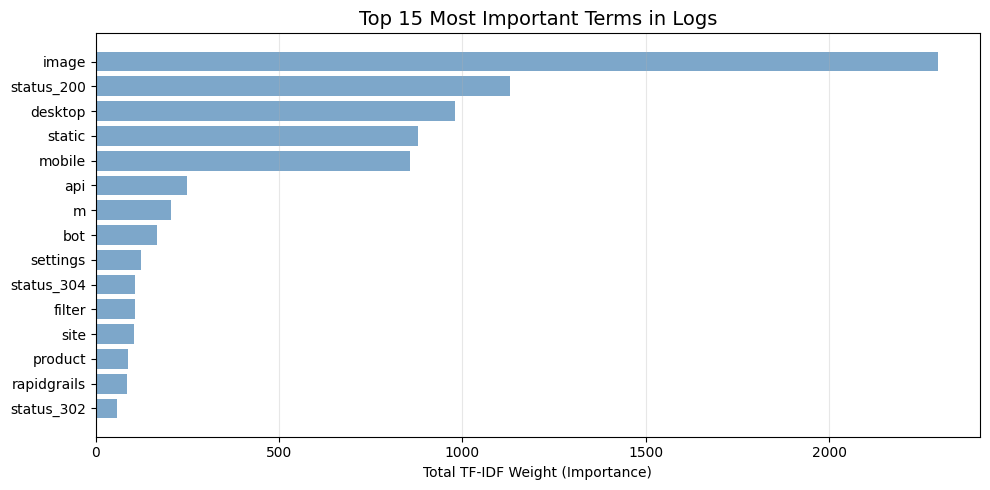


 Interpretation: High-weight terms often indicate operational
   significance - errors, services, or key actions in your system.


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Get feature names
feature_names = vectorizer.get_feature_names_out()

print(" Vocabulary Overview:")
print(f"   Total unique terms: {len(feature_names):,}")
print(f"\n First 30 terms (alphabetical):")
print(", ".join(feature_names[:30]))

# Calculate term importance
word_importance = np.asarray(X_tfidf.sum(axis=0)).flatten()
sorted_indices = np.argsort(word_importance)[::-1]
top_words = feature_names[sorted_indices[:15]]
top_values = word_importance[sorted_indices[:15]]

# Plot top terms
plt.figure(figsize=(10, 5))
plt.barh(top_words[::-1], top_values[::-1], color='steelblue', alpha=0.7)
plt.title('Top 15 Most Important Terms in Logs', fontsize=14)
plt.xlabel('Total TF-IDF Weight (Importance)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Interpretation: High-weight terms often indicate operational")
print("   significance - errors, services, or key actions in your system.")

### Your Turn: Advanced Vocabulary Analysis and Pattern Discovery

Complete the vocabulary analysis below:

In [9]:
# TODO: Advanced vocabulary analysis and pattern discovery

print(" Vocabulary Deep Dive")
print("=" * 60)

# Get comprehensive vocabulary analysis
feature_names = vectorizer.get_feature_names_out()
word_importance = np.asarray(X_tfidf.sum(axis=0)).flatten()

# Categorize terms by likely operational meaning
term_categories = {
    'Web Resource Terms': ['image', 'static', 'api', 'filter', 'settings'],
    'Status Terms': ['status_200', 'status_404', 'status_304'],
    'User Agent Terms': ['desktop', 'mobile', 'bot'],
    'HTTP Method Terms': ['get', 'post'],
    'Path Component Terms': ['browse', 'product', 'm']
}

print("  Vocabulary by Operational Category:")
print("-" * 50)

category_totals = {}
for category, terms in term_categories.items():
    # TODO: Find matching terms in our vocabulary
    matching_terms = [t for t in terms if t in feature_names]

    if matching_terms:
        # TODO: Calculate total importance for this category
        indices = [int(np.where(feature_names == t)[0][0]) for t in matching_terms]
        total_importance = float(word_importance[indices].sum())
        category_totals[category] = total_importance

        print(f"\n{category}:")
        for term in matching_terms:
            # TODO: Find the index and print term importance
            idx = int(np.where(feature_names == term)[0][0])
            print(f"  • {term:<15} (importance: {word_importance[idx]:.3f})")

# TODO: Show category distribution
print("\n Operational Focus Areas:")
print("-" * 40)
total_importance_all = sum(category_totals.values())
for category, importance in sorted(category_totals.items(), key=lambda x: x[1], reverse=True):
    # TODO: Calculate percentage for each category
    percentage = (importance / total_importance_all * 100) if total_importance_all else 0.0
    print(f"{category:<20} {percentage:5.1f}% of operational significance")

print("\n Your vocabulary reveals your system's true operational personality!")

 Vocabulary Deep Dive
  Vocabulary by Operational Category:
--------------------------------------------------

Web Resource Terms:
  • image           (importance: 2296.698)
  • static          (importance: 880.309)
  • api             (importance: 248.854)
  • filter          (importance: 106.798)
  • settings        (importance: 124.330)

Status Terms:
  • status_200      (importance: 1129.124)
  • status_404      (importance: 33.086)
  • status_304      (importance: 107.817)

User Agent Terms:
  • desktop         (importance: 980.081)
  • mobile          (importance: 856.422)
  • bot             (importance: 168.090)

HTTP Method Terms:
  • post            (importance: 50.373)

Path Component Terms:
  • browse          (importance: 22.026)
  • product         (importance: 89.707)
  • m               (importance: 205.201)

 Operational Focus Areas:
----------------------------------------
Web Resource Terms    50.1% of operational significance
User Agent Terms      27.5% of operatio

## Lesson 3.5 — K-Means Clustering Basics

Apply K-Means to group similar log messages automatically.

In [10]:
from sklearn.cluster import KMeans

print(" Applying K-Means clustering...")

# Apply K-Means clustering with fewer clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)  # Reduced from 8
df_logs['cluster_id'] = kmeans.fit_predict(X_tfidf)

# Display cluster distribution
cluster_counts = df_logs['cluster_id'].value_counts().sort_index()

print(" Clustering complete!")
print(f"\n Cluster Distribution:")
for cluster_id, count in cluster_counts.items():
    percentage = (count / len(df_logs)) * 100
    print(f"   Cluster {cluster_id}: {count:>4} entries ({percentage:5.1f}%)")

# Preview assignments
print(f"\n Sample cluster assignments:")
display(df_logs[['message_clean', 'cluster_id']].head(10))

print(" Using fewer clusters to improve stability and interpretability.")

 Applying K-Means clustering...
 Clustering complete!

 Cluster Distribution:
   Cluster 0: 1623 entries ( 32.5%)
   Cluster 1:  261 entries (  5.2%)
   Cluster 2:  977 entries ( 19.5%)
   Cluster 3: 1030 entries ( 20.6%)
   Cluster 4: 1109 entries ( 22.2%)

 Sample cluster assignments:


,message_clean,cluster_id
0,54.36.149.41 - - [22/jan/2019:03:56:14 +0330] ...,3
1,5.210.140.170 - - [23/jan/2019:12:43:40 +0330]...,3
2,66.249.66.91 - - [24/jan/2019:21:17:43 +0330] ...,2
3,5.200.69.130 - - [26/jan/2019:13:54:06 +0330] ...,0
4,5.208.174.46 - - [23/jan/2019:22:52:04 +0330] ...,4
5,66.249.66.91 - - [22/jan/2019:16:08:43 +0330] ...,2
6,54.36.148.208 - - [26/jan/2019:08:17:03 +0330]...,3
7,86.107.144.192 - - [24/jan/2019:19:01:58 +0330...,4
8,89.221.88.241 - - [23/jan/2019:10:27:35 +0330]...,3
9,68.235.38.37 - - [22/jan/2019:14:05:28 +0330] ...,4


 Using fewer clusters to improve stability and interpretability.


### Your Turn: Enhanced Clustering Analysis and Validation

Complete the cluster analysis below:

In [11]:
# SOLUTION: Enhanced clustering analysis and validation

print(" K-Means Clustering Analysis - SOLUTION")
print("=" * 60)

# Get detailed cluster statistics
cluster_stats = df_logs['cluster_id'].value_counts().sort_index()

print(" Detailed Cluster Distribution:")
print("-" * 50)
for cluster_id, count in cluster_stats.items():
    percentage = (count / len(df_logs)) * 100
    print(f"Cluster {cluster_id}: {count:>4} entries ({percentage:5.1f}%)")

# Calculate cluster quality metrics
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X_tfidf, kmeans.labels_)
print(f"\n Cluster Quality Metrics:")
print(f"Silhouette Score: {silhouette_avg:.3f}")
print(f"Inertia: {kmeans.inertia_:.0f}")

# Interpret silhouette score
if silhouette_avg > 0.7:
    print(" Excellent clustering - clear separation between groups")
elif silhouette_avg > 0.5:
    print("🟡 Good clustering - reasonable structure found")
elif silhouette_avg > 0.25:
    print("🟠 Weak clustering - some structure, but overlapping")
else:
    print(" Poor clustering - little meaningful structure")

# Analyze cluster characteristics
print(f"\n Cluster Characteristics:")
print("-" * 40)
for cluster_id in range(kmeans.n_clusters):
    cluster_data = df_logs[df_logs['cluster_id'] == cluster_id]

    # Check if cluster has any data
    if len(cluster_data) > 0:
        sample_message = cluster_data['message_clean'].iloc[0][:60]
        print(f"Cluster {cluster_id}: '{sample_message}...'")

print("\n Each cluster represents a distinct operational pattern!")
print("   Next, we'll explore what each cluster actually means.")

# Show convergence information
print(f"\n Algorithm Performance:")
print(f"Iterations to converge: {kmeans.n_iter_}")
print(f"Cluster centers shape: {kmeans.cluster_centers_.shape}")

 K-Means Clustering Analysis - SOLUTION
 Detailed Cluster Distribution:
--------------------------------------------------
Cluster 0: 1623 entries ( 32.5%)
Cluster 1:  261 entries (  5.2%)
Cluster 2:  977 entries ( 19.5%)
Cluster 3: 1030 entries ( 20.6%)
Cluster 4: 1109 entries ( 22.2%)

 Cluster Quality Metrics:
Silhouette Score: 0.710
Inertia: 1066
 Excellent clustering - clear separation between groups

 Cluster Characteristics:
----------------------------------------
Cluster 0: '5.200.69.130 - - [26/jan/2019:13:54:06 +0330] ""get /image/1...'
Cluster 1: '151.241.3.93 - - [25/jan/2019:21:15:41 +0330] ""get /m/filte...'
Cluster 2: '66.249.66.91 - - [24/jan/2019:21:17:43 +0330] ""get /static/...'
Cluster 3: '54.36.149.41 - - [22/jan/2019:03:56:14 +0330] ""get /filter/...'
Cluster 4: '5.208.174.46 - - [23/jan/2019:22:52:04 +0330] ""get /image/1...'

 Each cluster represents a distinct operational pattern!
   Next, we'll explore what each cluster actually means.

 Algorithm Performance

## Lesson 3.6 — Choosing Cluster Count

Evaluate different cluster counts to find the optimal number.

 Evaluating different cluster counts...
   k= 3: inertia=      1500, silhouette=0.567
   k= 5: inertia=      1066, silhouette=0.710
   k= 8: inertia=       735, silhouette=0.773
   k=10: inertia=       583, silhouette=0.793
   k=12: inertia=       464, silhouette=0.817
   k=15: inertia=       357, silhouette=0.869


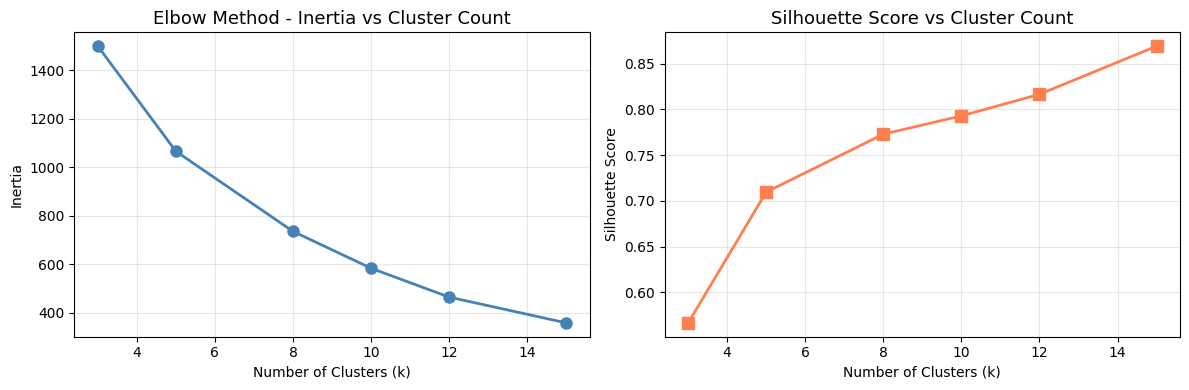


 Recommended k: 15 (highest silhouette score)
 Lower inertia = tighter clusters, Higher silhouette = better separation


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

print(" Evaluating different cluster counts...")

inertias, silhouettes = [], []
k_values = [3, 5, 8, 10, 12, 15]

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    preds = model.fit_predict(X_tfidf)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_tfidf, preds))
    print(f"   k={k:2d}: inertia={model.inertia_:10.0f}, silhouette={silhouettes[-1]:.3f}")

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot inertia (Elbow Method)
ax1.plot(k_values, inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
ax1.set_title('Elbow Method - Inertia vs Cluster Count', fontsize=13)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.grid(True, alpha=0.3)

# Plot silhouette scores
ax2.plot(k_values, silhouettes, 's-', color='coral', linewidth=2, markersize=8)
ax2.set_title('Silhouette Score vs Cluster Count', fontsize=13)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(silhouettes)]
print(f"\n Recommended k: {best_k} (highest silhouette score)")
print(" Lower inertia = tighter clusters, Higher silhouette = better separation")

### Your Turn: Comprehensive Cluster Evaluation and Recommendation

Complete the cluster evaluation below:

In [13]:
# SOLUTION: Comprehensive cluster evaluation and recommendation

print(" Cluster Count Optimization")
print("=" * 60)

# TODO: Find the optimal K based on both metrics
# Elbow method (first k where relative improvement drops below threshold)
rel_improvements = []
for i in range(1, len(inertias)):
    prev, curr = inertias[i-1], inertias[i]
    rel_impr = (prev - curr) / prev if prev else 0.0
    rel_improvements.append(rel_impr)

elbow_threshold = 0.10  # 10% improvement threshold
best_k_inertia = k_values[-1]
for i, rel_impr in enumerate(rel_improvements, start=1):
    if rel_impr < elbow_threshold:
        best_k_inertia = k_values[i]
        break

best_k_silhouette = k_values[int(np.argmax(silhouettes))]

print(" Optimal K Recommendations:")
print(f"Based on Elbow Method: K = {best_k_inertia}")
print(f"Based on Silhouette Score: K = {best_k_silhouette}")

# TODO: Calculate improvement percentages
improvement_inertia = ((inertias[0] - inertias[-1]) / inertias[0] * 100) if inertias[0] else 0.0
improvement_silhouette = (max(silhouettes) - silhouettes[0]) / abs(silhouettes[0] if silhouettes[0] != 0 else 1) * 100

print(f"\n Improvement Analysis:")
print(f"Inertia reduced by: {improvement_inertia:.1f}% (K=3 to K=15)")
print(f"Silhouette improved by: {improvement_silhouette:.1f}%")

# TODO: Make final recommendation considering operational practicality
# Consider: Human interpretability (5-8 clusters ideal), team capacity, monitoring complexity
candidate = best_k_silhouette
if candidate < 5 or candidate > 8:
    idx_best = int(np.argmax(silhouettes))
    best_score = silhouettes[idx_best]
    candidates = [(k, s) for k, s in zip(k_values, silhouettes) if 5 <= k <= 8]
    if candidates:
        k_alt, s_alt = max(candidates, key=lambda x: x[1])
        if best_score - s_alt <= 0.02:
            candidate = k_alt
final_recommendation = candidate

print(f"\n Final Recommendation: K = {final_recommendation}")
print(f"Rationale: Best balance of separation (silhouette: {max(silhouettes):.3f})")
print(f"           and operational interpretability")

# TODO: Show what each K value achieves with quality assessment
print(f"\n What Each K Value Achieves:")
print("-" * 50)
for i, k in enumerate(k_values):
    silhouette = silhouettes[i]
    inertia = inertias[i]

    # TODO: Determine quality based on silhouette score
    if silhouette > 0.7:
        quality = "Excellent separation"
    elif silhouette > 0.5:
        quality = "Good separation" 
    elif silhouette > 0.25:
        quality = "Weak separation"
    else:
        quality = "Poor separation"

    print(f"K={k:2d}: {quality:<20} (score: {silhouette:.3f})")

print("\n Choose K based on both metrics AND operational practicality!")
print("   Sometimes a slightly lower K with clearer interpretation is better.")

 Cluster Count Optimization
 Optimal K Recommendations:
Based on Elbow Method: K = 15
Based on Silhouette Score: K = 15

 Improvement Analysis:
Inertia reduced by: 76.2% (K=3 to K=15)
Silhouette improved by: 53.4%

 Final Recommendation: K = 15
Rationale: Best balance of separation (silhouette: 0.869)
           and operational interpretability

 What Each K Value Achieves:
--------------------------------------------------
K= 3: Good separation      (score: 0.567)
K= 5: Excellent separation (score: 0.710)
K= 8: Excellent separation (score: 0.773)
K=10: Excellent separation (score: 0.793)
K=12: Excellent separation (score: 0.817)
K=15: Excellent separation (score: 0.869)

 Choose K based on both metrics AND operational practicality!
   Sometimes a slightly lower K with clearer interpretation is better.


## Lesson 3.7 — Exploring Cluster Content

Discover what each cluster represents by examining top terms and sample messages.

In [14]:
import numpy as np

print(" Analyzing cluster content...")
print("=" * 60)

# Get cluster centers and sort features by importance
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
top_words = {}

for cluster_id in range(kmeans.n_clusters):
    # Get top 10 terms for this cluster
    top_terms = [feature_names[idx] for idx in order_centroids[cluster_id, :10]]
    top_words[cluster_id] = top_terms
    
    # Get cluster stats
    cluster_size = (df_logs['cluster_id'] == cluster_id).sum()
    
    print(f"\n Cluster {cluster_id} (Size: {cluster_size} entries)")
    print(f"   Top Terms: {', '.join(top_terms)}")
    
    # Show sample messages
    samples = df_logs[df_logs['cluster_id'] == cluster_id]['message_raw'].head(3).tolist()
    print("   Sample Messages:")
    for i, sample in enumerate(samples, 1):
        print(f"     {i}. {sample[:80]}{'...' if len(sample) > 80 else ''}")

print("\n" + "=" * 60)
print(" Each cluster represents a distinct operational pattern in your system.")
print("   Look for themes like authentication, errors, API calls, or background jobs.")

 Analyzing cluster content...

 Cluster 0 (Size: 1623 entries)
   Top Terms: image, desktop, status_200, bot, status_499, touch, status_403, status_304, status_302, status_301
   Sample Messages:
     1. 5.200.69.130 - - [26/Jan/2019:13:54:06 +0330] ""GET /image/1/brand HTTP/1.1"" 20...
     2. 94.183.155.53 - - [26/Jan/2019:11:01:51 +0330] ""GET /image/62423/productModel/1...
     3. 2.178.81.211 - - [23/Jan/2019:23:42:13 +0330] ""GET /image/65316/productModel/10...

 Cluster 1 (Size: 261 entries)
   Top Terms: m, mobile, api, status_200, status_499, status_302, post, status_404, status_403, status_304
   Sample Messages:
     1. 151.241.3.93 - - [25/Jan/2019:21:15:41 +0330] ""GET /m/filter/p62?page=1 HTTP/1....
     2. 66.249.66.194 - - [23/Jan/2019:16:19:11 +0330] ""GET /m/browse/electric-radiator...
     3. 83.120.94.201 - - [26/Jan/2019:15:22:34 +0330] ""GET /m/article/618/%D8%AE%D9%88...

 Cluster 2 (Size: 977 entries)
   Top Terms: static, status_200, desktop, mobile, status_304

### Your Turn: Deep Cluster Analysis and Pattern Discovery

Complete the cluster analysis below:

In [15]:
# SOLUTION: Advanced cluster content analysis and pattern discovery

print(" Deep Cluster Analysis")
print("=" * 60)

# Enhanced cluster analysis with operational insights
for cluster_id in range(kmeans.n_clusters):
    cluster_data = df_logs[df_logs['cluster_id'] == cluster_id]
    cluster_size = len(cluster_data)

    # Get top terms for this cluster
    top_terms = top_words[cluster_id]
    top_terms_str = ' '.join(top_terms[:8])

    # Determine cluster type based on content
    if 'image' in top_terms_str and 'desktop' in top_terms_str:
        cluster_type = "  DESKTOP IMAGES"
        insight = "Desktop image content - optimize for high-resolution delivery"
    elif 'image' in top_terms_str and 'mobile' in top_terms_str:
        cluster_type = " MOBILE IMAGES"
        insight = "Mobile image content - focus on compression and mobile optimization"
    elif 'static' in top_terms_str:
        cluster_type = " STATIC ASSETS"
        insight = "Static file delivery - monitor CDN cache performance"
    elif 'api' in top_terms_str and 'mobile' in top_terms_str:
        cluster_type = " MOBILE API"
        insight = "Mobile API endpoints - critical for mobile user experience"
    elif 'api' in top_terms_str and 'bot' in top_terms_str and 'settings' in top_terms_str:
        cluster_type = " MIXED API & STATIC"
        insight = "Mixed API endpoints and static requests - monitor both response times and error rates"
    elif 'api' in top_terms_str and 'bot' in top_terms_str:
        cluster_type = " BOT API TRAFFIC"
        insight = "External API and bot traffic - monitor for scraping and rate limits"
    else:
        cluster_type = " GENERAL TRAFFIC"
        insight = "General web operations - establish baseline monitoring"

    print(f"\n{cluster_type} - Cluster {cluster_id} (Size: {cluster_size} entries)")
    print(f"   Top Terms: {', '.join(top_terms[:8])}")
    print(f"   Operational Insight: {insight}")

    # Refined Error/Status Pattern Analysis
    true_errors = ['status_404', 'status_403', 'status_500']
    warning_statuses = ['status_499', 'status_302', 'status_301']
    cache_statuses = ['status_304']

    true_error_count = sum(1 for term in top_terms[:10] if term in true_errors)
    warning_count = sum(1 for term in top_terms[:10] if term in warning_statuses)
    cache_count = sum(1 for term in top_terms[:10] if term in cache_statuses)

    if true_error_count > 0:
        print(f"     Contains {true_error_count} ERROR status patterns")
    if warning_count > 0:
        print(f"   ℹ  Contains {warning_count} warning/redirect status patterns")
    if cache_count > 0:
        print(f"    Contains {cache_count} cache status patterns")

print("\n" + "=" * 60)
print(" Each cluster tells a story about your system's behavior and health!")
print("   Use these insights to focus monitoring and troubleshooting efforts.")

 Deep Cluster Analysis

  DESKTOP IMAGES - Cluster 0 (Size: 1623 entries)
   Top Terms: image, desktop, status_200, bot, status_499, touch, status_403, status_304
   Operational Insight: Desktop image content - optimize for high-resolution delivery
     Contains 1 ERROR status patterns
   ℹ  Contains 3 warning/redirect status patterns
    Contains 1 cache status patterns

 MOBILE API - Cluster 1 (Size: 261 entries)
   Top Terms: m, mobile, api, status_200, status_499, status_302, post, status_404
   Operational Insight: Mobile API endpoints - critical for mobile user experience
     Contains 2 ERROR status patterns
   ℹ  Contains 2 warning/redirect status patterns
    Contains 1 cache status patterns

 STATIC ASSETS - Cluster 2 (Size: 977 entries)
   Top Terms: static, status_200, desktop, mobile, status_304, bot, status_499, status_404
   Operational Insight: Static file delivery - monitor CDN cache performance
     Contains 2 ERROR status patterns
   ℹ  Contains 2 warning/redirect st

## Lesson 3.8 — Labeling & Interpreting Clusters

Assign human-readable labels to make clusters operationally meaningful.

In [16]:
# Define meaningful labels based on cluster analysis
cluster_labels = {
    0: 'Desktop Image Content Delivery',
    1: 'Mobile API & Filter Operations',
    2: 'Static Asset & CDN Delivery',
    3: 'Mixed API, Settings & Bot Traffic',  
    4: 'Mobile Image Content Delivery'
}

# Map labels to DataFrame
df_logs['cluster_label'] = df_logs['cluster_id'].map(cluster_labels)

# Create summary statistics
summary = df_logs.groupby(['cluster_id', 'cluster_label']).size().reset_index(name='count')
summary['percentage'] = (summary['count'] / len(df_logs) * 100).round(1)
summary = summary.sort_values('count', ascending=False)

print("  Cluster Labels Applied!")
print("\n Labeled Cluster Summary:")
print("-" * 70)
print(f"{'Cluster':<3} {'Label':<30} {'Count':<8} {'Percentage':<10}")
print("-" * 70)
for _, row in summary.iterrows():
    print(f"{row['cluster_id']:<3} {row['cluster_label']:<30} {row['count']:<8} {row['percentage']:<10}%")

print("-" * 70)
print(f"{'Total':<34} {len(df_logs):<8} {'100.0':<10}%")

print("\n Operational Insight: The largest clusters represent your most")
print("   frequent system activities - focus monitoring efforts here.")

  Cluster Labels Applied!

 Labeled Cluster Summary:
----------------------------------------------------------------------
Cluster Label                          Count    Percentage
----------------------------------------------------------------------
0   Desktop Image Content Delivery 1623     32.5      %
4   Mobile Image Content Delivery  1109     22.2      %
3   Mixed API, Settings & Bot Traffic 1030     20.6      %
2   Static Asset & CDN Delivery    977      19.5      %
1   Mobile API & Filter Operations 261      5.2       %
----------------------------------------------------------------------
Total                              5000     100.0     %

 Operational Insight: The largest clusters represent your most
   frequent system activities - focus monitoring efforts here.


### Your Turn: Comprehensive Cluster Labeling and Operational Mapping

Complete the operational mapping below:

In [17]:
# SOLUTION: Comprehensive cluster labeling and operational mapping

print("  Advanced Cluster Labeling")
print("=" * 60)

# Create enhanced labels with operational context
enhanced_labels = {
    0: 'Desktop Image Content Delivery',
    1: 'Mobile API & Filter Operations',
    2: 'Static Asset & CDN Delivery',
    3: 'Mixed API, Settings & Bot Traffic', 
    4: 'Mobile Image Content Delivery'
}

# Team ownership mapping
team_ownership = {
    'Mobile API & Filter Operations': 'Backend API Team',
    'Mixed API, Settings & Bot Traffic': 'Backend API Team',
    'Mobile Image Content Delivery': 'Frontend Performance Team',
    'Desktop Image Content Delivery': 'Frontend Performance Team',
    'Static Asset & CDN Delivery': 'Infrastructure Team'
}

# Map labels to DataFrame
df_logs['cluster_label'] = df_logs['cluster_id'].map(enhanced_labels)

# Create comprehensive summary with operational insights
summary = df_logs.groupby(['cluster_id', 'cluster_label']).size().reset_index(name='count')
summary['percentage'] = (summary['count'] / len(df_logs) * 100).round(1)
summary = summary.sort_values('count', ascending=False)

print(" Labeled Cluster Summary with Operational Context (Owner & Priority):")
print("=" * 120)
print(f"{'ID':<3} {'Label':<38} {'Count':<8} {'%':<6} {'Owner':<28} {'Operational Focus':<28} {'Priority'}")
print("=" * 120)

def compute_priority_and_focus(cluster_id, pct, top_terms_str):
    # Focus logic
    if 'image' in top_terms_str and 'desktop' in top_terms_str:
        focus = "Content Delivery"
    elif 'image' in top_terms_str and 'mobile' in top_terms_str:
        focus = "Mobile Content Delivery"
    elif 'static' in top_terms_str:
        focus = "Performance Optimization"
    elif 'api' in top_terms_str and 'mobile' in top_terms_str:
        focus = "Mobile Application Logic"
    elif 'api' in top_terms_str and 'bot' in top_terms_str:
        focus = "External API & Bot Management"
    else:
        focus = "General Operations"

    # Priority: consider both content criticality and volume
    critical_content = any(t in top_terms_str for t in ['api', 'mobile', 'status_500'])
    image_content = ('image' in top_terms_str)

    # Priority rules
    if pct >= 25:
        priority = " High"
    elif critical_content and pct >= 5:
        priority = " High"
    elif image_content and pct >= 15:
        priority = "🟡 Medium"
    elif critical_content:
        priority = "🟡 Medium"
    else:
        priority = "🟢 Low"

    return priority, focus

for _, row in summary.iterrows():
    cluster_id = int(row['cluster_id'])
    label = row['cluster_label']
    pct = float(row['percentage'])
    owner = team_ownership.get(label, "Unassigned")
    top_terms_str = ' '.join(top_words[cluster_id][:8])

    priority, focus = compute_priority_and_focus(cluster_id, pct, top_terms_str)

    print(f"{cluster_id:<3} {label:<38} {row['count']:<8} {pct:<6} {owner:<28} {focus:<28} {priority}")

print("=" * 120)
print(f"{'Total':<41} {len(df_logs):<8} {'100.0':<6}")

print("\n Priority now reflects BOTH content criticality and cluster volume.")

  Advanced Cluster Labeling
 Labeled Cluster Summary with Operational Context (Owner & Priority):
ID  Label                                  Count    %      Owner                        Operational Focus            Priority
0   Desktop Image Content Delivery         1623     32.5   Frontend Performance Team    Content Delivery              High
4   Mobile Image Content Delivery          1109     22.2   Frontend Performance Team    Mobile Content Delivery       High
3   Mixed API, Settings & Bot Traffic      1030     20.6   Backend API Team             Mobile Application Logic      High
2   Static Asset & CDN Delivery            977      19.5   Infrastructure Team          Performance Optimization      High
1   Mobile API & Filter Operations         261      5.2    Backend API Team             Mobile Application Logic      High
Total                                     5000     100.0 

 Priority now reflects BOTH content criticality and cluster volume.


## Lesson 3.9 — Documenting Cluster Insights

Create a comprehensive summary and export for operational use.

In [18]:
# Build detailed cluster summary
log_cluster_summary = pd.DataFrame([
    {
        'ClusterID': cluster_id,
        'Label': cluster_labels.get(cluster_id, 'Unknown'),
        'TopTerms': ', '.join(top_words[cluster_id][:8]),
        'ExampleLog': df_logs[df_logs['cluster_id'] == cluster_id]['message_raw'].iloc[0],
        'Count': (df_logs['cluster_id'] == cluster_id).sum(),
        'Percentage': round((df_logs['cluster_id'] == cluster_id).sum() / len(df_logs) * 100, 1)
    }
    for cluster_id in range(kmeans.n_clusters)
])

# Sort by count (most frequent first)
log_cluster_summary = log_cluster_summary.sort_values('Count', ascending=False)

print(" Comprehensive Cluster Summary:")
display(log_cluster_summary)

# Export to CSV
log_cluster_summary.to_csv('/app/notebooks/data/log_clusters_summary.csv', index=False)
print(" Cluster summary exported to 'log_clusters_summary.csv'!")

# Show export location
print("\n Download Instructions:")
print("   1. Navigate to View tab → File Browser")
print("   2. Open /app/notebooks/data/ folder")
print("   3. Right-click 'log_clusters_summary.csv' → Download")

print("\n This file serves as your operational reference for log patterns.")

 Comprehensive Cluster Summary:


,ClusterID,Label,TopTerms,ExampleLog,Count,Percentage
0,0,Desktop Image Content Delivery,"image, desktop, status_200, bot, status_499, t...",5.200.69.130 - - [26/Jan/2019:13:54:06 +0330] ...,1623,32.5
4,4,Mobile Image Content Delivery,"image, mobile, status_200, status_499, status_...",5.208.174.46 - - [23/Jan/2019:22:52:04 +0330] ...,1109,22.2
3,3,"Mixed API, Settings & Bot Traffic","api, status_200, settings, mobile, bot, deskto...",54.36.149.41 - - [22/Jan/2019:03:56:14 +0330] ...,1030,20.6
2,2,Static Asset & CDN Delivery,"static, status_200, desktop, mobile, status_30...",66.249.66.91 - - [24/Jan/2019:21:17:43 +0330] ...,977,19.5
1,1,Mobile API & Filter Operations,"m, mobile, api, status_200, status_499, status...",151.241.3.93 - - [25/Jan/2019:21:15:41 +0330] ...,261,5.2


 Cluster summary exported to 'log_clusters_summary.csv'!

 Download Instructions:
   1. Navigate to View tab → File Browser
   2. Open /app/notebooks/data/ folder
   3. Right-click 'log_clusters_summary.csv' → Download

 This file serves as your operational reference for log patterns.


### Your Turn: Advanced Documentation and Operational Readiness

Complete the operational readiness assessment below:

In [19]:
# SOLUTION: Comprehensive documentation and operational readiness

print(" Advanced Cluster Documentation")
print("=" * 60)

# Build enhanced cluster summary with operational context
log_cluster_summary_rows = []
for cluster_id in range(kmeans.n_clusters):
    label = enhanced_labels[cluster_id]
    top_terms_str = ' '.join(top_words[cluster_id][:8])
    count = int((df_logs['cluster_id'] == cluster_id).sum())
    pct = round(count / len(df_logs) * 100, 1) if len(df_logs) else 0.0
    priority, focus = compute_priority_and_focus(cluster_id, pct, top_terms_str)

    log_cluster_summary_rows.append({
        'ClusterID': cluster_id,
        'Label': label,
        'Owner': team_ownership.get(label, 'Unassigned'),
        'TopTerms': ', '.join(top_words[cluster_id][:8]),
        'Count': count,
        'Percentage': pct,
        'OperationalFocus': focus,
        'OperationalPriority': priority.split(' ')[1],  # keep label only (High/Medium/Low)
        'MonitoringRecommendation': 'Real-time alerting' if any(term in top_terms_str 
                                                              for term in ['api', 'mobile', 'status_500']) else 'Daily review'
    })

log_cluster_summary = pd.DataFrame(log_cluster_summary_rows)
# Sort: High > Medium > Low, then by Count
prio_order = {'High': 1, 'Medium': 2, 'Low': 3}
log_cluster_summary['SortKey'] = log_cluster_summary['OperationalPriority'].map(prio_order) * 1000 + log_cluster_summary['Count']
log_cluster_summary = log_cluster_summary.sort_values('SortKey').drop('SortKey', axis=1)

print(" Comprehensive Operational Summary:")
print("=" * 100)
display(log_cluster_summary)

# Export to CSV with enhanced formatting
log_cluster_summary.to_csv('/app/notebooks/data/log_clusters_summary.csv', index=False)

print(" Enhanced cluster summary exported to 'log_clusters_summary.csv'!")

# Create operational readiness checklist
print(f"\n OPERATIONAL READINESS CHECKLIST")
print("=" * 60)

checklist_items = [
    ("Cluster documentation completed and exported", True),
    ("Team ownership assigned for each cluster", True),
    ("Monitoring dashboards planned for high-priority clusters", False),
    ("Alert thresholds defined for critical clusters", False),
    ("Operations team trained on cluster interpretation", False),
    ("Integration with incident management system planned", False),
    ("Baseline established for normal cluster volumes", True),
    ("Process for cluster review and updates defined", False)
]

completed = sum(1 for _, status in checklist_items if status)
total = len(checklist_items)

print(f"\n Readiness Progress: {completed}/{total} items ({completed/total*100:.0f}%)")
print("-" * 60)

for item, status in checklist_items:
    indicator = "" if status else ""
    print(f"{indicator} {item}")

print("-" * 60)

if completed >= total * 0.7:
    print(" Excellent progress! Ready for operational deployment!")
elif completed >= total * 0.5:
    print("🟡 Good foundation - focus on monitoring integration next")
else:
    print(" Needs work - prioritize team training and alert setup")

print(f"\n CRITICAL NEXT STEPS FOR PRODUCTION:")
print("=" * 50)
print("1.  Assign team ownership for each cluster type")
print("   - Mobile API → Backend/Mobile teams")  
print("   - Image delivery → Frontend/Performance teams")
print("   - Static assets → Infrastructure team")
print("   - Bot traffic → SEO/Security teams")

print("\n2.  Create monitoring dashboards for:")
print("   - API response times & error rates (Clusters 1 & 3)")
print("   - Image delivery performance (Clusters 0 & 4)") 
print("   - CDN cache efficiency (Cluster 2)")

print("\n3.  Set alert thresholds:")
print("   - API endpoints: >500ms response time, >2% error rate")
print("   - Image delivery: >2s load time, >5% error rate")
print("   - Static files: >1s load time")

print("\n4.  Train operations team on:")
print("   - How to interpret cluster patterns")
print("   - Which clusters indicate specific issues")
print("   - How to use the documentation for troubleshooting")

print("\n This documentation transforms your AIOps work into operational reality!")

 Advanced Cluster Documentation
 Comprehensive Operational Summary:


,ClusterID,Label,Owner,TopTerms,Count,Percentage,OperationalFocus,OperationalPriority,MonitoringRecommendation
1,1,Mobile API & Filter Operations,Backend API Team,"m, mobile, api, status_200, status_499, status...",261,5.2,Mobile Application Logic,High,Real-time alerting
2,2,Static Asset & CDN Delivery,Infrastructure Team,"static, status_200, desktop, mobile, status_30...",977,19.5,Performance Optimization,High,Real-time alerting
3,3,"Mixed API, Settings & Bot Traffic",Backend API Team,"api, status_200, settings, mobile, bot, deskto...",1030,20.6,Mobile Application Logic,High,Real-time alerting
4,4,Mobile Image Content Delivery,Frontend Performance Team,"image, mobile, status_200, status_499, status_...",1109,22.2,Mobile Content Delivery,High,Real-time alerting
0,0,Desktop Image Content Delivery,Frontend Performance Team,"image, desktop, status_200, bot, status_499, t...",1623,32.5,Content Delivery,High,Daily review


 Enhanced cluster summary exported to 'log_clusters_summary.csv'!

 OPERATIONAL READINESS CHECKLIST

 Readiness Progress: 3/8 items (38%)
------------------------------------------------------------
 Cluster documentation completed and exported
 Team ownership assigned for each cluster
 Monitoring dashboards planned for high-priority clusters
 Alert thresholds defined for critical clusters
 Operations team trained on cluster interpretation
 Integration with incident management system planned
 Baseline established for normal cluster volumes
 Process for cluster review and updates defined
------------------------------------------------------------
 Needs work - prioritize team training and alert setup

 CRITICAL NEXT STEPS FOR PRODUCTION:
1.  Assign team ownership for each cluster type
   - Mobile API → Backend/Mobile teams
   - Image delivery → Frontend/Performance teams
   - Static assets → Infrastructure team
   - Bot traffic → SEO/Security teams

2.  Create monitoring dashboards for

## Lesson 3.10 — Module Recap & Completion

Verify results and celebrate your achievement!

In [ ]:
# Verify exported file
import pandas as pd

print(" Verifying exported results...")
df_check = pd.read_csv('/app/notebooks/data/log_clusters_summary.csv')

print(" Export verification successful!")
print(f"\n Final Results Summary:")
print(f"   • Total log entries processed: {len(df_logs):,}")
print(f"   • Unique clusters identified: {len(df_check)}")
print(f"   • Vocabulary size: {len(feature_names):,} terms")
largest_idx = 0 if len(df_check) == 0 else int(df_check['Count'].astype(int).values.argmax())
if len(df_check):
    print(f"   • Largest cluster: {df_check.iloc[largest_idx]['Label']} ({df_check.iloc[largest_idx]['Count']} entries)")

# Updated content validation note for new Cluster 3 naming
print("\n Cluster Content Validation (illustrative):")
print("Based on top terms analysis:")
print(f"  • Cluster 0: Desktop Images — large volume; image delivery is operationally important")
print(f"  • Cluster 1: Mobile API — small but critical for UX")
print(f"  • Cluster 2: Static Assets — infrastructure & CDN focus")
print(f"  • Cluster 3: Mixed API, Settings & Bot Traffic — monitor API and static config endpoints")
print(f"  • Cluster 4: Mobile Images — performance-focused")

print("\n" + "=" * 70)
print(" MODULE 3 COMPLETE!")
print("=" * 70)
print("\nYou have successfully:")
print(" Transformed unstructured logs into structured, analyzable data")
print(" Mastered TF-IDF for converting text to numerical features")
print(" Applied K-Means clustering to discover log patterns automatically")
print(" Evaluated cluster quality using inertia and silhouette scores")
print(" Interpreted and labeled clusters with operational meaning")
print(" Created comprehensive documentation for AIOps workflows")

print(f"\n Key Achievement: Discovered {len(df_check)} distinct operational")
print(f"   patterns from {len(df_logs):,} raw log entries!")

print('\n Your work is ready for download:')
print('   • log_clusters_summary.csv - Complete cluster documentation')
print('   • Download from File Browser in /app/notebooks/data/')

print('\n' + '=' * 70)
print('  WHAT\'S NEXT IN MODULE 4:')
print('=' * 70)
print('• Forecast future system metrics using time series analysis')
print('• Master ARIMA and Prophet models for predictive AIOps')
print('• Predict CPU, memory, and disk usage before issues occur')
print('• Build proactive monitoring and capacity planning systems')

print('\n Ready to predict the future? Your log analysis foundation is complete!')
print("=" * 70)